In [1]:
import pdb,sys,os
import warnings
warnings.filterwarnings('ignore')
import anndata as ad
import scanpy as sc
sc.settings.verbosity = 0
import argparse
import copy
import numpy as np
import scipy
import timeit

from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
from typing import Tuple

In [ ]:
import scSemiProfiler as semi
from scSemiProfiler.utils import *

## Single-cell deconvolution pipeline
This example is for the scenario where the users wish to use scSemiProfiler to deconvolution bulk data of a target sample to single-cell data, providing the bulk and single-cell of reference data. The input format is the same as before. Bulk data of representatives and target samples to deconvolute need to be concatenated together as an h5ad file. Sample IDs should be stored in adata.obs['sample_ids'] and gene names should be stored in adata.var.index. The single-cell reference data is also provided as an h5ad file as the representative before. The model reconstructs the reference and then use tgtinfer function to infer the single-cell data of any target sample. Once target sample's single-cell data is generated, the user can annotate the cell type in various ways, e.g. de novo cell type annotation using any tool. Here we train a classifier using the reference data and then annotate the generated target sample using the classifier. 


## Step 1: Initial setup: bulk data preparation and reference sample specification

In [ ]:
# 'bulkdata.h5ad' contains the reference data and the target bulk data to deconvolute
name = 'deconvolution_CD451_10'
bulk = './Bulk_Rna_CD45_1_filtered.h5ad' 
logged = False
normed = True
geneselection = False
batch = 2

In [5]:
# run the same initial setup
semi.initsetup(name,bulk,logged=logged,normed=normed,geneselection=geneselection,batch=batch)

Start initial setup
Initial setup finished. Among 5 total samples, selected 2 representatives:
wm3
wm4


In [8]:
# view bulk samples

bulkdata = anndata.read_h5ad(bulk)
for i, sid in enumerate(bulkdata.obs['sample_ids']):
    print(i,sid)
bulkdata

0 wm1
1 wm2
2 wm3
3 wm4
4 wm5


AnnData object with n_obs × n_vars = 5 × 1079
    obs: 'sample_ids'
    var: 'gene_symbols'

In [ ]:
# select 6 as reference data, setup representative and obtain representative single-cell data
set_representatives(name=name, representatives_list = [1])

## Step 2: Reference data processing

In [8]:
# single-cell processing of the reference data
semi.scprocess(name=name,singlecell=name+'/scRNA_CD45_1_norm_filtered.h5ad',normed=True,logged=False,cellfilter=False,threshold=1e-3,geneset=True,weight=0.5,k=15)

Processing representative single-cell data
Removing background noise
Computing human geneset scores
GMT file c2.cp.v7.4.symbols.gmt loading ... 
2922
Number of genes in c2.cp.v7.4.symbols.gmt 756
Augmenting and saving single-cell data.
Finished processing representative single-cell data


## Step 3: Infer target sample single-cell data

pretrain 1: representative reconstruction


CUDA backend failed to initialize: Unable to load CUDA. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


INFO     Generating sequential column names                                                                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 100/100: 100%|██████████| 100/100 [02:29<00:00,  1.63s/it, v_num=1, train_loss_step=270, train_loss_epoch=282]

...

Epoch 150/150: 100%|██████████| 150/150 [01:07<00:00,  2.23it/s, v_num=1, train_loss_step=447, train_loss_epoch=432]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 150/150: 100%|██████████| 150/150 [01:07<00:00,  2.60it/s, v_num=1, train_loss_step=523, train_loss_epoch=542]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150: 100%|██████████| 150/150 [01:07<00:00,  2.22it/s, v_num=1, train_loss_step=523, train_loss_epoch=542]
Finished target sample single-cell inference
INFO     Generating sequential column names                                                                        


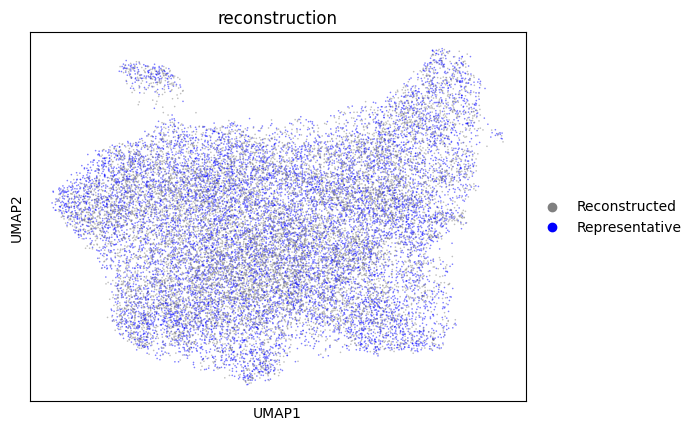

pretrain 1: representative reconstruction
load existing pretrain 1 reconstruction model for wm2
INFO     Generating sequential column names                                                                        
pretrain2: reconstruction with representative bulk loss
load existing pretrain 2 model for wm2
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 150/150: 100%|██████████| 150/150 [01:12<00:00,  2.42it/s, v_num=1, train_loss_step=258, train_loss_epoch=261]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150: 100%|██████████| 150/150 [01:12<00:00,  2.07it/s, v_num=1, train_loss_step=258, train_loss_epoch=261]


...

Epoch 150/150: 100%|██████████| 150/150 [01:11<00:00,  2.10it/s, v_num=1, train_loss_step=294, train_loss_epoch=293]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 150/150: 100%|██████████| 150/150 [01:11<00:00,  2.46it/s, v_num=1, train_loss_step=313, train_loss_epoch=309]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150: 100%|██████████| 150/150 [01:11<00:00,  2.09it/s, v_num=1, train_loss_step=313, train_loss_epoch=309]
Finished target sample single-cell inference
INFO     Generating sequential column names                                                                        


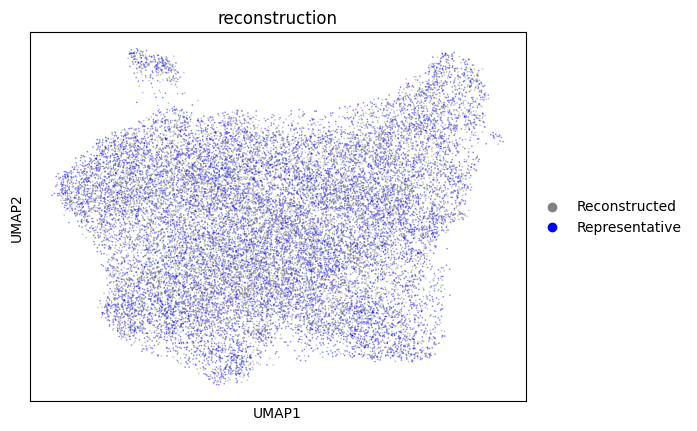

pretrain 1: representative reconstruction
load existing pretrain 1 reconstruction model for wm2
INFO     Generating sequential column names                                                                        
pretrain2: reconstruction with representative bulk loss
load existing pretrain 2 model for wm2
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 150/150: 100%|██████████| 150/150 [01:22<00:00,  2.41it/s, v_num=1, train_loss_step=278, train_loss_epoch=278]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150: 100%|██████████| 150/150 [01:22<00:00,  1.81it/s, v_num=1, train_loss_step=278, train_loss_epoch=278]


...

Epoch 150/150: 100%|██████████| 150/150 [01:09<00:00,  2.17it/s, v_num=1, train_loss_step=418, train_loss_epoch=412]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 150/150: 100%|██████████| 150/150 [01:10<00:00,  2.26it/s, v_num=1, train_loss_step=505, train_loss_epoch=505]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150: 100%|██████████| 150/150 [01:10<00:00,  2.14it/s, v_num=1, train_loss_step=505, train_loss_epoch=505]
Finished target sample single-cell inference
INFO     Generating sequential column names                                                                        


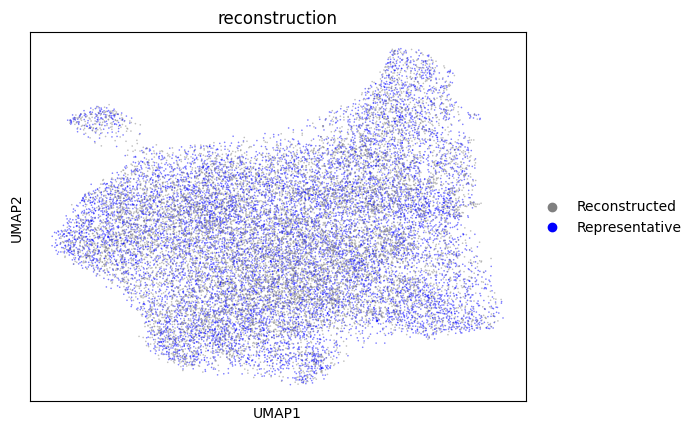

pretrain 1: representative reconstruction
load existing pretrain 1 reconstruction model for wm2
INFO     Generating sequential column names                                                                        
pretrain2: reconstruction with representative bulk loss
load existing pretrain 2 model for wm2
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        
INFO     Generating sequential column names                                                                        


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 150/150: 100%|██████████| 150/150 [01:09<00:00,  2.46it/s, v_num=1, train_loss_step=257, train_loss_epoch=260]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150: 100%|██████████| 150/150 [01:09<00:00,  2.15it/s, v_num=1, train_loss_step=257, train_loss_epoch=260]


...

Epoch 150/150: 100%|██████████| 150/150 [01:09<00:00,  2.14it/s, v_num=1, train_loss_step=302, train_loss_epoch=297]


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3,4,5,6,7]


Epoch 150/150: 100%|██████████| 150/150 [01:09<00:00,  2.39it/s, v_num=1, train_loss_step=321, train_loss_epoch=314]

`Trainer.fit` stopped: `max_epochs=150` reached.


Epoch 150/150: 100%|██████████| 150/150 [01:09<00:00,  2.17it/s, v_num=1, train_loss_step=321, train_loss_epoch=314]
Finished target sample single-cell inference
INFO     Generating sequential column names                                                                        


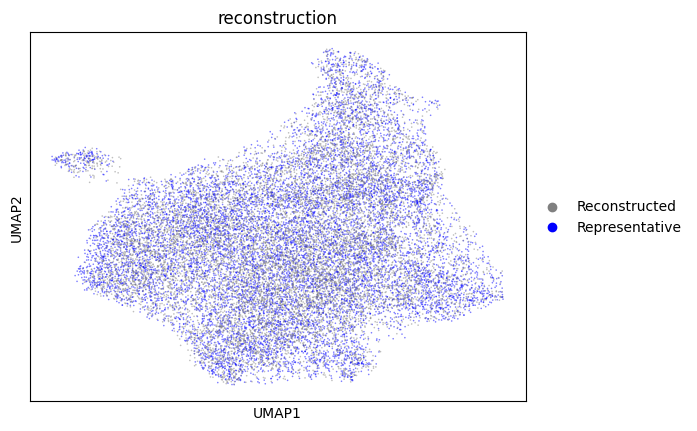

In [9]:
# use the reference data to infer the target single-cell data
# e.g. infer sample 1's single-cell
for i in [0,2,3,4]:
    semi.tgtinfer(name = name, representative = 1, target = i, bulktype='real',device='cuda:7', pseudocount=0.1)
    visualize_recon(name, 1)


After inference, a cell-by-gene matrix for the target sample will be stored in 'name/inferreddata/reference_to_target.npy'. We convert it to h5ad for downstream task - cell type annotation.

In [ ]:
# list inferred target sample:
os.listdir(name + '/inferreddata')

In [12]:
# convert to anndata object
tgt_mtx = np.load(name + '/inferreddata/wm2_to_wm1.npy')
tgtdata = anndata.AnnData(tgt_mtx)
tgtdata.var.index = bulkdata.var.index # add gene names

In [ ]:
import os
import numpy as np
import anndata as ad

inferred_data_dir = name + '/inferreddata'

npy_files = [os.path.join(inferred_data_dir, file) for file in os.listdir(inferred_data_dir) if file.endswith('.npy')]

adata_list = []
for file in npy_files:
    print(f"Processing file: {file}")
    tgt_mtx = np.load(file)
    tgtdata = ad.AnnData(tgt_mtx)
    tgtdata.var.index = bulkdata.var.index
    tgtdata.obs['source_file'] = os.path.basename(file).split(".")[0]
    print(tgtdata.obs['source_file'])
    adata_list.append(tgtdata)

Processing file: deconvolution_CD451_10/inferreddata/wm2_to_wm5.npy
0        wm2_to_wm5
1        wm2_to_wm5
2        wm2_to_wm5
3        wm2_to_wm5
4        wm2_to_wm5
            ...    
11079    wm2_to_wm5
11080    wm2_to_wm5
11081    wm2_to_wm5
11082    wm2_to_wm5
11083    wm2_to_wm5
Name: source_file, Length: 11084, dtype: object
Processing file: deconvolution_CD451_10/inferreddata/wm2_to_wm4.npy
0        wm2_to_wm4
1        wm2_to_wm4
2        wm2_to_wm4
3        wm2_to_wm4
4        wm2_to_wm4
            ...    
11079    wm2_to_wm4
11080    wm2_to_wm4
11081    wm2_to_wm4
11082    wm2_to_wm4
11083    wm2_to_wm4
Name: source_file, Length: 11084, dtype: object
Processing file: deconvolution_CD451_10/inferreddata/wm2_to_wm3.npy
0        wm2_to_wm3
1        wm2_to_wm3
2        wm2_to_wm3
3        wm2_to_wm3
4        wm2_to_wm3
            ...    
11079    wm2_to_wm3
11080    wm2_to_wm3
11081    wm2_to_wm3
11082    wm2_to_wm3
11083    wm2_to_wm3
Name: source_file, Length: 11084, dtype:

In [ ]:
merged_adata = ad.concat(adata_list, axis=0)

output_file = inferred_data_dir + '/merged_inferred_CD45_1_data.h5ad'
merged_adata.write(output_file, compression="gzip")
print(f"Merged AnnData saved to: {output_file}")

Merged AnnData saved to: deconvolution_CD451_01/inferreddata/merged_inferred_CD45_1_data.h5ad


## Step 4: Cell type annotation for target single-cell data

### Option 1: De novo annotation
The user can choose any existing methods to annotate the generated single-cell matrix, for example:
[Cellar](https://github.com/euxhenh/cellar) or [Scanpy](https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html#dimensionality-reduction) (note: The data is already preprocessed. Please start from the 'dimensionality-reduction' step.)


### Option 2: Annotate using a classifier trained on reference samples
We can train a classifier usign the reference samples and use it to annotate the target sample.

In [ ]:
import anndata as ad
adata = ad.read_h5ad("./merged_ingest.h5ad")
scdata = ad.read_h5ad("./deconvolution_CD451_10/scRNA_CD45_1_norm_filtered.h5ad")
common_cells = scdata.obs.index.intersection(adata.obs.index)
adata.obs["leiden_Macro_short"] = adata.obs["leiden_Macro_short"].astype(str)
scdata.obs.loc[common_cells, "celltypes"] = adata.obs.loc[common_cells, "leiden_Macro_short"]

In [ ]:
# get training data
name = 'deconvolution_CD451_10'
reference_x = np.log1p(scdata.X)
reference_y = np.array(scdata.obs['celltypes']) # reference data cell types

In [ ]:
inferred_data_dir = name + '/inferreddata'
npy_files = [os.path.join(inferred_data_dir, file) for file in os.listdir(inferred_data_dir) if file.endswith('.npy')]
adata_list = []
for file in npy_files:
    print(f"Processing file: {file}")
    tgt_mtx = np.load(file)
    tgtdata = ad.AnnData(tgt_mtx)
    tgtdata.var.index = bulkdata.var.index
    tgtdata.obs['source_file'] = os.path.basename(file).split(".")[0]
    print(tgtdata.obs['source_file'])
    target_x = np.log1p(tgtdata.X)
    annotator = MLPClassifier(hidden_layer_sizes=(200,))
    print('Training cell type annotator.')
    st =  timeit.default_timer()
    annotator.fit((reference_x),reference_y)
    ed =  timeit.default_timer()
    print('Finished. Cost ' + str(ed-st) + ' seconds.')
    predicted_celltype = annotator.predict(target_x)
    tgtdata.obs['celltypes'] = predicted_celltype
    adata_list.append(tgtdata)
    merged_adata = ad.concat(adata_list, axis=0)

output_file = inferred_data_dir + '/merged_inferred_CD45_1_data_labelled_ingest.h5ad'
merged_adata.write(output_file, compression="gzip")
print(f"Merged AnnData saved to: {output_file}")

Processing file: deconvolution_CD451_10/inferreddata/wm2_to_wm5.npy
0        wm2_to_wm5
1        wm2_to_wm5
2        wm2_to_wm5
3        wm2_to_wm5
4        wm2_to_wm5
            ...    
11079    wm2_to_wm5
11080    wm2_to_wm5
11081    wm2_to_wm5
11082    wm2_to_wm5
11083    wm2_to_wm5
Name: source_file, Length: 11084, dtype: object
Training cell type annotator.
Finished. Cost 162.43013851344585 seconds.
Processing file: deconvolution_CD451_10/inferreddata/wm2_to_wm4.npy
0        wm2_to_wm4
1        wm2_to_wm4
2        wm2_to_wm4
3        wm2_to_wm4
4        wm2_to_wm4
            ...    
11079    wm2_to_wm4
11080    wm2_to_wm4
11081    wm2_to_wm4
11082    wm2_to_wm4
11083    wm2_to_wm4
Name: source_file, Length: 11084, dtype: object
Training cell type annotator.
Finished. Cost 161.35209518717602 seconds.
Processing file: deconvolution_CD451_10/inferreddata/wm2_to_wm3.npy
0        wm2_to_wm3
1        wm2_to_wm3
2        wm2_to_wm3
3        wm2_to_wm3
4        wm2_to_wm3
            ..

In [15]:
output_file = inferred_data_dir + '/merged_inferred_CD45_1_data_labelled.h5ad'
tgtdata.write(output_file, compression="gzip")